Défi quotidien : Analyse stratégique de la performance des supermarchés.

In [13]:
#Chargement et préparation


import pandas as pd              
import numpy as np                
import matplotlib.pyplot as plt   
import seaborn as sns             
import ipywidgets as widgets     
from ipywidgets import interact, Dropdown, IntSlider  # les widgets qu'on va utiliser
from IPython.display import display  # pour afficher proprement dans Jupyter
import warnings
warnings.filterwarnings('ignore')  # on masque les avertissements pour garder la sortie propre


# encoding='latin1' est nécessaire car le fichier contient des caractères spéciaux
df = pd.read_csv('superstore_dataset.csv', encoding='latin1')

# On affiche les dimensions du dataset : (nombre de lignes, nombre de colonnes)
print("Dimensions du dataset:", df.shape)

# On affiche la liste de toutes les colonnes disponibles
print("\nNoms des colonnes:")
print(df.columns.tolist())

# df.info() donne un résumé : types de données et valeurs manquantes par colonne
display(df.info())

# df.describe() donne les statistiques de base : moyenne, min, max, etc.
display(df.describe())

# On compte les valeurs manquantes dans chaque colonne
print("\nValeurs manquantes par colonne:")
print(df.isnull().sum())

# On vérifie s'il y a des lignes en double dans le dataset
print("\nLignes dupliquées:", df.duplicated().sum())

# On supprime les doublons pour éviter de fausser les analyses
df = df.drop_duplicates()

# La colonne Postal Code peut avoir des cases vides
# On les remplace par 0 plutôt que de supprimer toute la ligne
if 'Postal Code' in df.columns:
    df['Postal Code'] = df['Postal Code'].fillna(0)

# On convertit les colonnes de dates en format datetime
# Sans cette conversion, Pandas traite les dates comme du texte simple
# et on ne peut pas faire d'analyse temporelle (par mois, par année...)
date_columns = ['Order Date', 'Ship Date']
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

# On vérifie que la conversion a bien fonctionné
print("\nTypes après conversion:")
print(df[date_columns].dtypes)

# On crée de nouvelles colonnes utiles pour l'analyse
# La marge bénéficiaire indique le pourcentage de profit par rapport aux ventes
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

# On extrait l'année et le mois de la date de commande
# Cela permet de regrouper les ventes par période
df['Order Year']  = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month

# On crée une colonne combinée "Mois-Année" pour l'analyse mensuelle
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

# On affiche un aperçu des nouvelles colonnes créées
print("\nAperçu des nouvelles colonnes:")
print(df[['Sales', 'Profit', 'Profit Margin', 'Order Year', 'Order Month']].head())

Dimensions du dataset: (9994, 21)

Noms des colonnes:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code  

None

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000



Valeurs manquantes par colonne:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Lignes dupliquées: 0

Types après conversion:
Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

Aperçu des nouvelles colonnes:
      Sales    Profit  Profit Margin  Order Year  Order Month
0  261.9600   41.9136          16.00        2016           11
1  731.9400  219.5820          30.00        2016           11
2   14.6200    6.8714          47.00        2016            6
3  957.5775 -383.0310         -40.00        2015           10
4   22.3680    2.5164          11.25        2015           10


In [14]:
#Séries temporelles

# On regroupe les ventes par mois et par catégorie de produit
# reset_index() transforme le résultat en tableau normal
monthly_sales = df.groupby(['Order Month-Year', 'Category'])['Sales'].sum().reset_index()

# On convertit la colonne Mois-Année en format date pour pouvoir la tracer sur un graphique
monthly_sales['Date'] = monthly_sales['Order Month-Year'].dt.to_timestamp()

# Cette fonction crée un graphique de ventes mensuelles
# Elle accepte un paramètre "category" pour filtrer par catégorie de produit
def plot_monthly_sales(category='All'):
    plt.figure(figsize=(12, 6))

    if category == 'All':
        # On regroupe toutes les ventes par mois sans distinction de catégorie
        total_monthly = df.groupby('Order Month-Year')['Sales'].sum()
        plt.plot(total_monthly.index.to_timestamp(), total_monthly.values,
                 marker='o', linewidth=2, markersize=4, color='steelblue')
        plt.title('Tendance des ventes mensuelles — Toutes categories',
                  fontsize=16, fontweight='bold')
    else:
        # On filtre uniquement les données de la catégorie sélectionnée
        cat_data = monthly_sales[monthly_sales['Category'] == category]
        plt.plot(cat_data['Date'], cat_data['Sales'],
                 marker='o', linewidth=2, markersize=4, color='darkorange')
        plt.title(f'Tendance des ventes mensuelles — {category}',
                  fontsize=16, fontweight='bold')

    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Ventes ($)', fontsize=12)
    plt.xticks(rotation=45)       # on incline les dates pour qu'elles ne se chevauchent pas
    plt.grid(True, alpha=0.3)     # grille légère pour faciliter la lecture
    plt.tight_layout()            # ajuste automatiquement les marges
    plt.show()

# On construit la liste des catégories disponibles en ajoutant "All" en premier
categories = ['All'] + list(df['Category'].unique())

# interact() connecte la fonction au menu déroulant
# chaque fois que l'utilisateur change la catégorie, le graphique se met à jour
interact(plot_monthly_sales, category=Dropdown(
    options=categories, value='All', description='Categorie:'));

interactive(children=(Dropdown(description='Categorie:', options=('All', 'Furniture', 'Office Supplies', 'Tech…

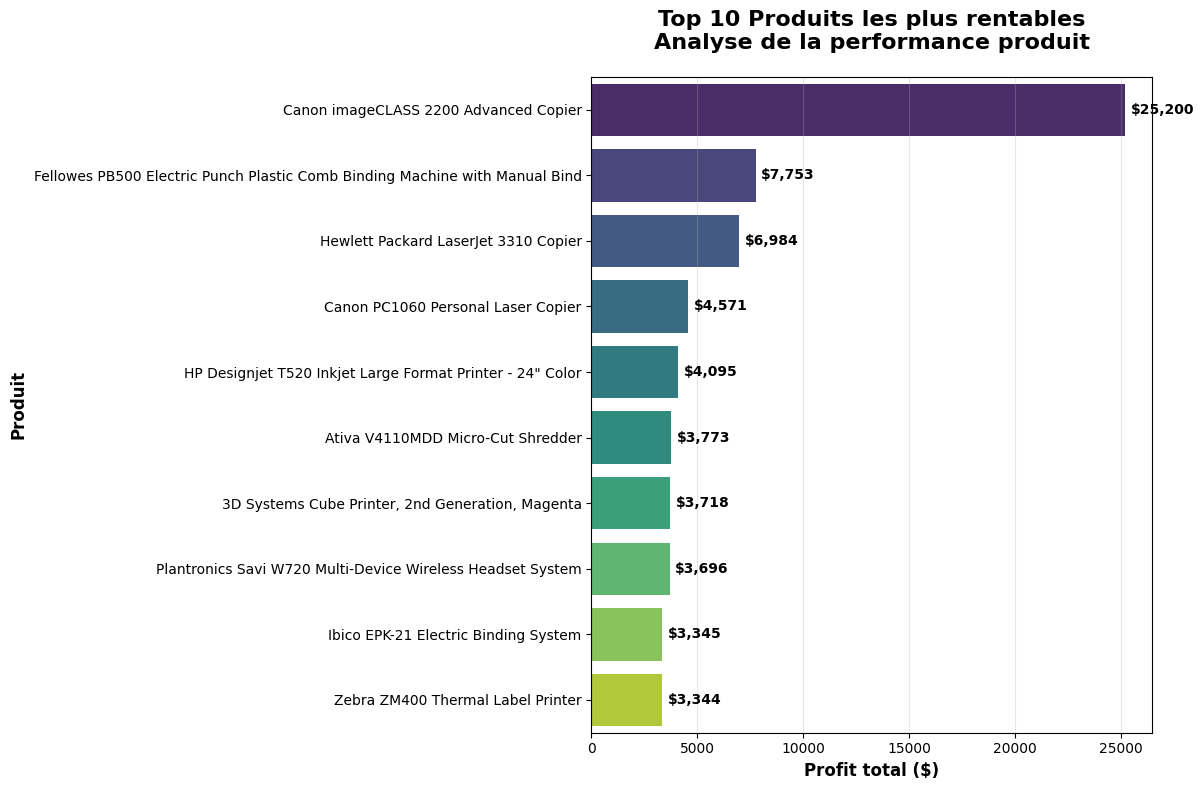

Produit le plus rentable : $25,200
Profit cumulé du top 10  : $66,479
Profit moyen du top 10   : $6,648


In [15]:
#Top 10 produits rentables


# On regroupe les profits par produit, on trie et on garde les 10 premiers
product_profit = (df.groupby('Product Name')['Profit']
                    .sum()
                    .sort_values(ascending=False)
                    .head(10))

plt.figure(figsize=(12, 8))

# orient='h' pour des barres horizontales, plus lisibles avec des noms de produits longs
ax = sns.barplot(x=product_profit.values, y=product_profit.index,
                 palette='viridis', orient='h')

plt.title('Top 10 Produits les plus rentables\nAnalyse de la performance produit',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Profit total ($)', fontsize=12, fontweight='bold')
plt.ylabel('Produit', fontsize=12, fontweight='bold')

# On ajoute le montant exact de profit sur chaque barre pour faciliter la lecture
for i, (product, profit) in enumerate(product_profit.items()):
    ax.text(profit + max(product_profit.values) * 0.01, i,
            f'${profit:,.0f}', va='center', fontweight='bold', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# On affiche des chiffres clés en dessous du graphique
print(f"Produit le plus rentable : ${product_profit.iloc[0]:,.0f}")
print(f"Profit cumulé du top 10  : ${product_profit.sum():,.0f}")
print(f"Profit moyen du top 10   : ${product_profit.mean():,.0f}")

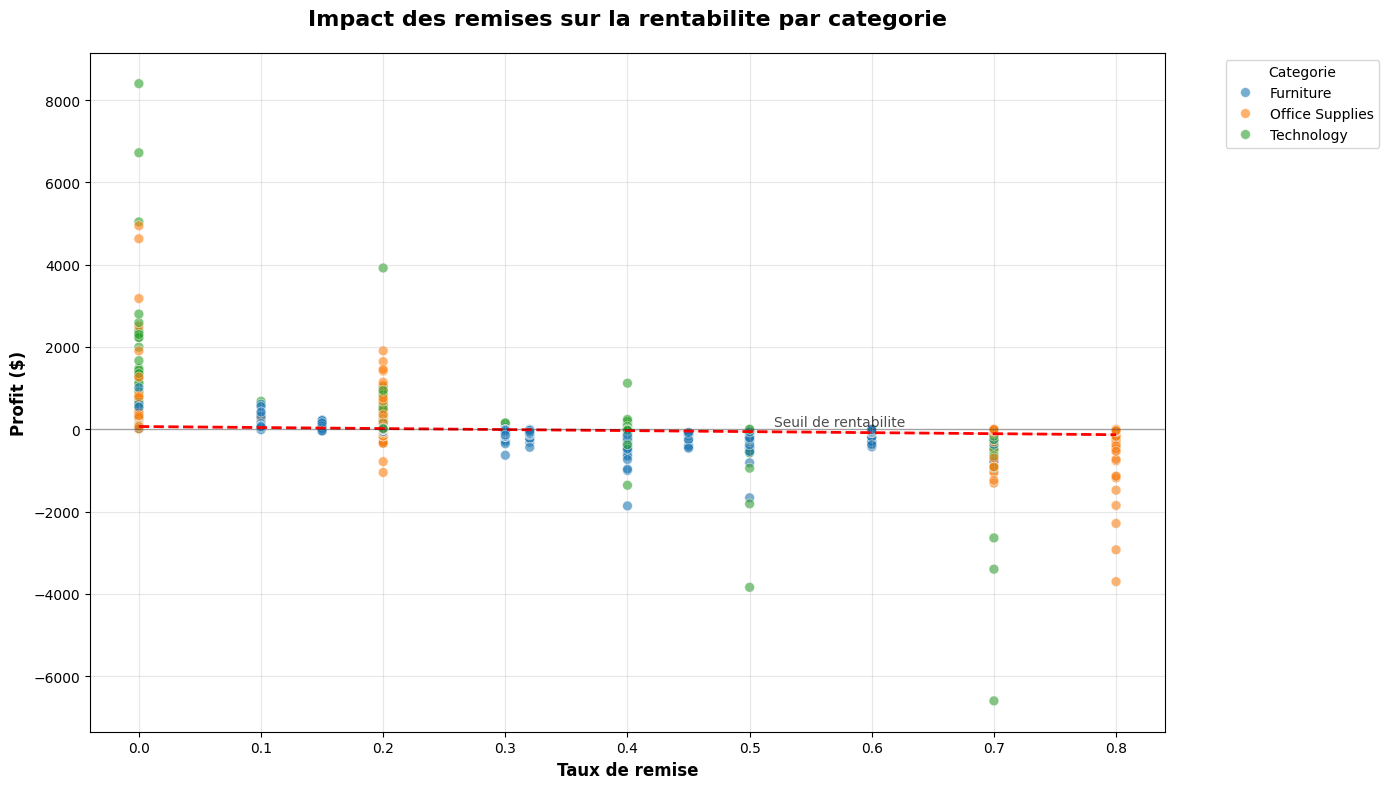

Transactions avec remise >20%  : 1,393
Profit moyen sur ces ventes    : $-97.18
Pourcentage en perte           : 96.8%
Furniture : profit moyen a >20% de remise = $-100.51
Office Supplies : profit moyen a >20% de remise = $-69.32
Technology : profit moyen a >20% de remise = $-197.42


In [16]:
#Remise vs Profit

plt.figure(figsize=(14, 8))

# Chaque point représente une transaction
# La couleur indique la catégorie de produit (hue)
# alpha=0.6 rend les points semi-transparents pour voir les superpositions
sns.scatterplot(data=df, x='Discount', y='Profit',
                hue='Category', alpha=0.6, s=50)

# regplot ajoute une droite de tendance qui montre l'évolution générale
# scatter=False signifie qu'on veut uniquement la droite, pas les points en double
sns.regplot(data=df, x='Discount', y='Profit', scatter=False,
            color='red', line_kws={'linewidth': 2, 'linestyle': '--'})

# Ligne horizontale à y=0 : en dessous = perte, au dessus = profit
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
plt.text(0.52, 80, 'Seuil de rentabilite', fontsize=10, alpha=0.7)

plt.title('Impact des remises sur la rentabilite par categorie',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Taux de remise', fontsize=12, fontweight='bold')
plt.ylabel('Profit ($)', fontsize=12, fontweight='bold')
plt.legend(title='Categorie', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# On filtre les transactions avec une remise supérieure à 20%
high_discount = df[df['Discount'] > 0.2]

print(f"Transactions avec remise >20%  : {len(high_discount):,}")
print(f"Profit moyen sur ces ventes    : ${high_discount['Profit'].mean():.2f}")
print(f"Pourcentage en perte           : {(high_discount['Profit'] < 0).mean()*100:.1f}%")

# On analyse l'impact des remises élevées pour chaque catégorie séparément
for cat in df['Category'].unique():
    hd = df[(df['Category'] == cat) & (df['Discount'] > 0.2)]
    if len(hd) > 0:
        print(f"{cat} : profit moyen a >20% de remise = ${hd['Profit'].mean():.2f}")


In [17]:
#Comparaison Matplotlib vs Seaborn


import time

print("=== COMPARAISON DES BIBLIOTHEQUES ===\n")
print("MATPLOTLIB :")
print("- Controle precis de chaque element du graphique")
print("- S'integre bien avec ipywidgets pour l'interactivite")
print("- Ideal pour l'exploration rapide des donnees\n")

print("SEABORN :")
print("- Graphiques statistiques integres comme regplot")
print("- Palettes de couleurs professionnelles automatiques")
print("- Moins de code pour un resultat esthetique\n")

# On mesure le temps d'execution de chaque bibliotheque pour comparer leur rapidite
start = time.time()
plt.figure(figsize=(8, 6))
plt.plot(df.groupby('Order Year')['Sales'].sum())
plt.close()
t_mpl = time.time() - start

start = time.time()
plt.figure(figsize=(8, 6))
sns.lineplot(data=df.groupby('Order Year')['Sales'].sum().reset_index(),
             x='Order Year', y='Sales')
plt.close()
t_sns = time.time() - start

print(f"Matplotlib : {t_mpl:.4f} secondes")
print(f"Seaborn    : {t_sns:.4f} secondes")

=== COMPARAISON DES BIBLIOTHEQUES ===

MATPLOTLIB :
- Controle precis de chaque element du graphique
- S'integre bien avec ipywidgets pour l'interactivite
- Ideal pour l'exploration rapide des donnees

SEABORN :
- Graphiques statistiques integres comme regplot
- Palettes de couleurs professionnelles automatiques
- Moins de code pour un resultat esthetique

Matplotlib : 0.0305 secondes
Seaborn    : 0.0872 secondes


In [ ]:
#Résumé exécutif

print(" RESUME EXECUTIF — POINTS CLES\n")

# Calcul des indicateurs globaux de performance
total_sales  = df['Sales'].sum()
total_profit = df['Profit'].sum()
margin       = (total_profit / total_sales) * 100

print("PERFORMANCE GLOBALE :")
print(f"- Chiffre d'affaires total : ${total_sales:,.0f}")
print(f"- Profit total             : ${total_profit:,.0f}")
print(f"- Marge beneficiaire       : {margin:.1f}%\n")

# L'état avec les meilleures ventes est le dernier après le tri croissant
# On recalcule state_sales ici pour s'assurer qu'elle est disponible
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=True)
top_state       = state_sales.index[-1]
top_state_sales = state_sales.iloc[-1]

print("GEOGRAPHIE :")
print(f"- Meilleur etat  : {top_state} (${top_state_sales:,.0f})")
print(f"- Top 5 etats    : {(state_sales.tail(5).sum()/total_sales)*100:.1f}% des ventes\n")

# La catégorie avec le plus de ventes après tri décroissant
top_cat = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).index[0]

print("PRODUITS :")
print(f"- Categorie leader       : {top_cat}")
print(f"- Produit le + rentable  : {product_profit.index[0]}\n")

# Pourcentage de transactions à forte remise qui génèrent une perte
loss_rate = (df[df['Discount'] > 0.2]['Profit'] < 0).mean() * 100

print("STRATEGIE REMISES :")
print(f"- Remises >20% generant des pertes : {loss_rate:.1f}%")
print(f"- Seuil recommande                 : 20% maximum")

=== RESUME EXECUTIF — POINTS CLES ===

PERFORMANCE GLOBALE :
- Chiffre d'affaires total : $2,297,201
- Profit total             : $286,397
- Marge beneficiaire       : 12.5%

GEOGRAPHIE :
- Meilleur etat  : California ($457,688)
- Top 5 etats    : 52.0% des ventes

PRODUITS :
- Categorie leader       : Technology
- Produit le + rentable  : Canon imageCLASS 2200 Advanced Copier

STRATEGIE REMISES :
- Remises >20% generant des pertes : 96.8%
- Seuil recommande                 : 20% maximum


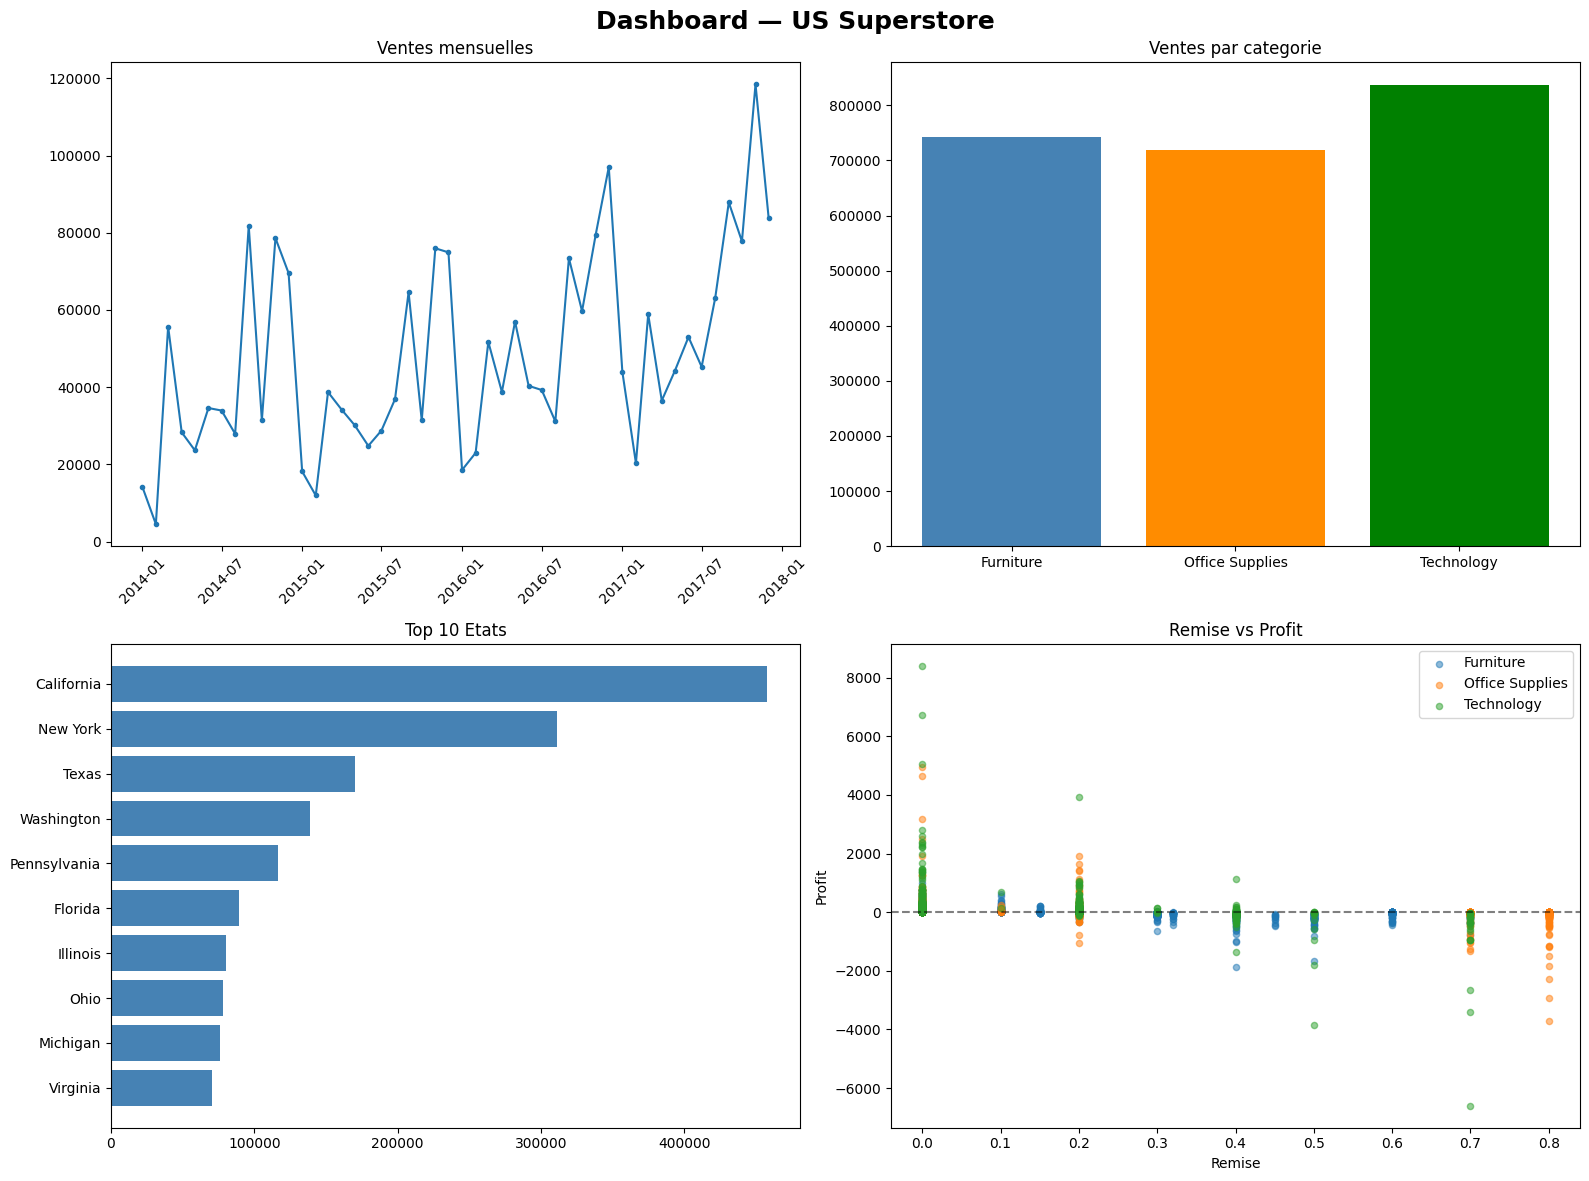

In [20]:
def create_dashboard():
    # On crée une figure avec 4 graphiques organisés en 2 lignes et 2 colonnes
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    # Graphique 1 : evolution des ventes mois par mois
    monthly_total = df.groupby('Order Month-Year')['Sales'].sum()
    ax1.plot(monthly_total.index.to_timestamp(), monthly_total.values,
             marker='o', markersize=3)
    ax1.set_title('Ventes mensuelles')
    ax1.tick_params(axis='x', rotation=45)

    # Graphique 2 : comparaison des ventes entre les 3 categories de produits
    cat_sales = df.groupby('Category')['Sales'].sum()
    ax2.bar(cat_sales.index, cat_sales.values,
            color=['steelblue', 'darkorange', 'green'])
    ax2.set_title('Ventes par categorie')

    # Graphique 3 : classement des 10 meilleurs etats en ventes
    top10 = state_sales.tail(10)
    ax3.barh(range(len(top10)), top10.values, color='steelblue')
    ax3.set_yticks(range(len(top10)))
    ax3.set_yticklabels(top10.index)
    ax3.set_title('Top 10 Etats')

    # Graphique 4 : impact des remises sur les profits, une couleur par categorie
    for cat in df['Category'].unique():
        d = df[df['Category'] == cat]
        ax4.scatter(d['Discount'], d['Profit'], label=cat, alpha=0.5, s=20)
    ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)  # ligne zero profit
    ax4.set_xlabel('Remise')
    ax4.set_ylabel('Profit')
    ax4.set_title('Remise vs Profit')
    ax4.legend()

    plt.suptitle('Dashboard — US Superstore', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

create_dashboard()